Importing Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score ,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Data Reading and Overview

In [4]:
data=pd.read_csv('employee analysis.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Checking Null Values and Datatypes of the columns

In [7]:
data.isnull().sum().sum()

0

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Description of each numeric column for Analysis

In [10]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Exploratory Data Analysis - Extracting Insights from Data Through Data Visualization

In [12]:
data['BusinessTravel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

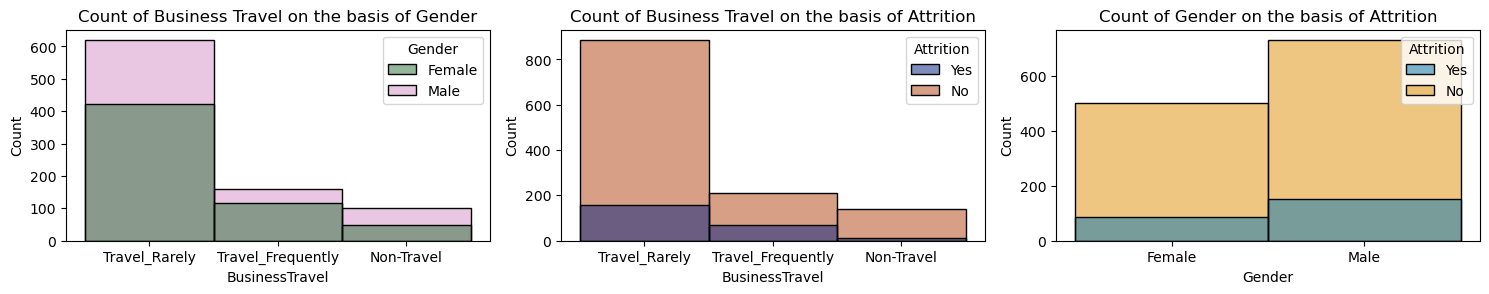

In [13]:
plt.figure(figsize=(15,8))
plt.subplot(3,3,1)
sns.histplot(x=data['BusinessTravel'],palette='cubehelix',hue=data['Gender'])
plt.title('Count of Business Travel on the basis of Gender')
plt.subplot(3,3,2)
sns.histplot(x=data['BusinessTravel'],bins=4,palette='dark',hue=data['Attrition'])
plt.title('Count of Business Travel on the basis of Attrition')
plt.tight_layout()
plt.subplot(3,3,3)
sns.histplot(x=data['Gender'],bins=4,palette='colorblind',hue=data['Attrition'])
plt.title('Count of Gender on the basis of Attrition')
plt.show()

Conclusion 1: Females travel Rarely .
 

Conclusion 2: On the basis of Business Travel - Most Attrition is from the people who Travel rarely 
 

conclusion 3: Still max Attrition is from the Male gender . 

In [17]:
data['EducationField'].value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

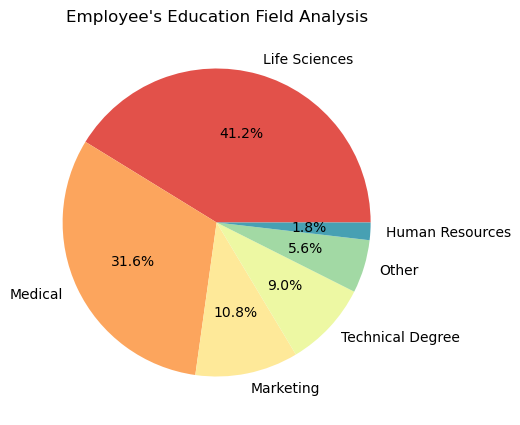

In [18]:
plt.figure(figsize=(7,5))
plt.pie(data['EducationField'].value_counts(), labels=data['EducationField'].value_counts().index,colors=sns.color_palette('Spectral'),autopct='%1.1f%%')
plt.title('Employee\'s Education Field Analysis')
plt.show()

Conclusion : Most employees are from-Life Sciences and Medical Field

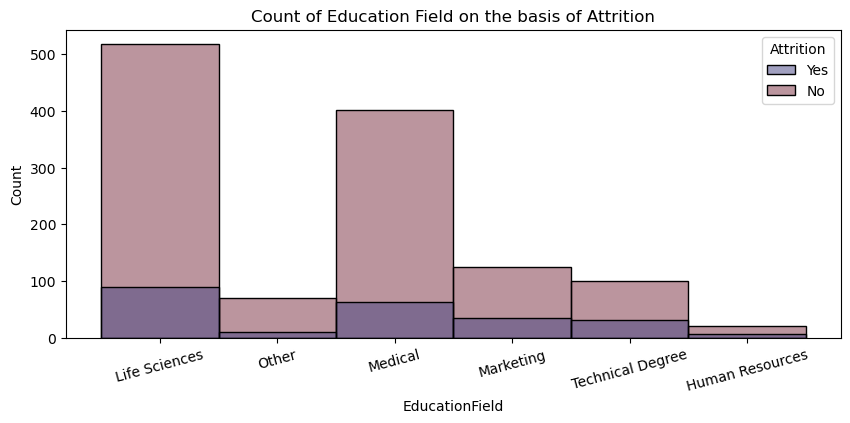

In [20]:
plt.figure(figsize=(10,4))
sns.histplot(x=data['EducationField'],palette='icefire',hue=data['Attrition'])
plt.title('Count of Education Field on the basis of Attrition')
plt.xticks(rotation=15)
plt.show()

Conclusion from the above : Employees from Life Sciences and Medical -Education Field are having most of the Attritions .

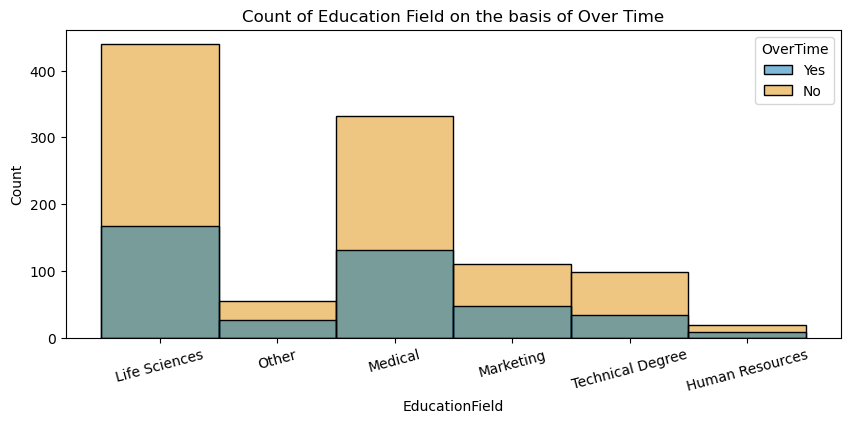

In [22]:
plt.figure(figsize=(10,4))
sns.histplot(x=data['EducationField'],palette='colorblind',hue=data['OverTime'])
plt.title('Count of Education Field on the basis of Over Time')
plt.xticks(rotation=15)
plt.show()

Conclusion : The Education Fields where Attrition is maximum is may be because of the Over Time 

In [24]:
data['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

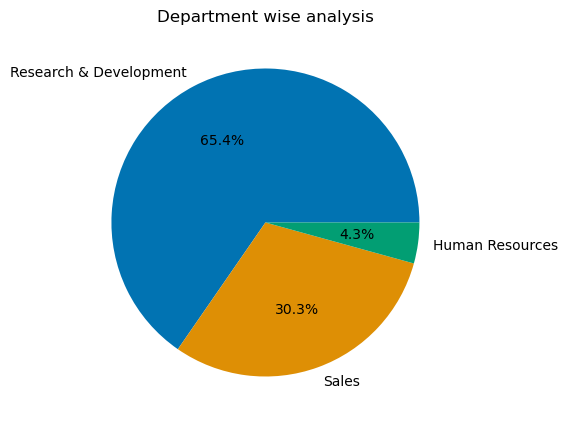

In [25]:
plt.figure(figsize=(7,5))
plt.pie(data['Department'].value_counts(), labels=data['Department'].value_counts().index,colors=sns.color_palette('colorblind'),autopct='%1.1f%%')
plt.title('Department wise analysis')
plt.show()

Conclusion : Most of the employees are from Research and development and also Sales

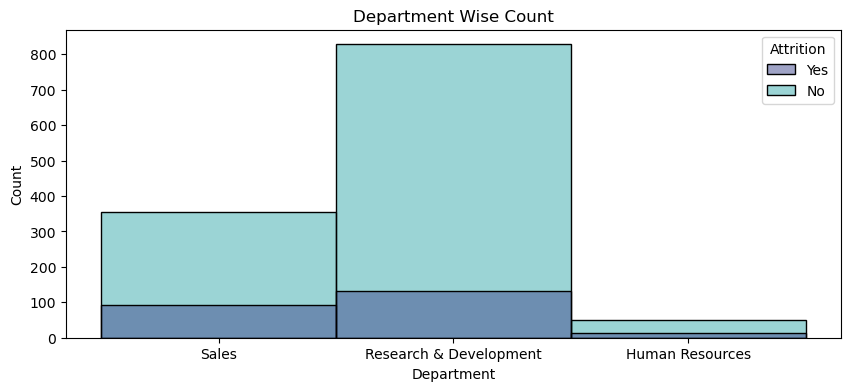

In [27]:
plt.figure(figsize=(10,4))
sns.histplot(x=data['Department'],palette='mako',hue=data['Attrition'])
plt.title('Department Wise Count')
plt.show()

Conclusion : The Attrition is maximum in Rsearch and Development Department and Sales

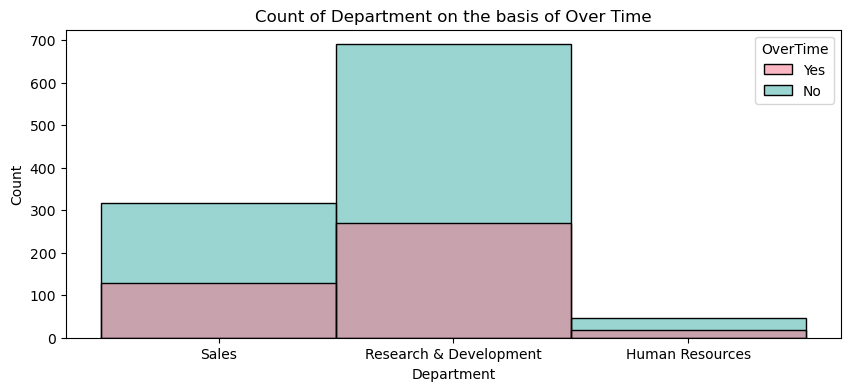

In [29]:
plt.figure(figsize=(10,4))
sns.histplot(x=data['Department'],palette='husl',hue=data['OverTime'])
plt.title('Count of Department on the basis of Over Time')
plt.show()

Conclusion : The department of Research and Development where Attrition was high , is may be because of Over Time

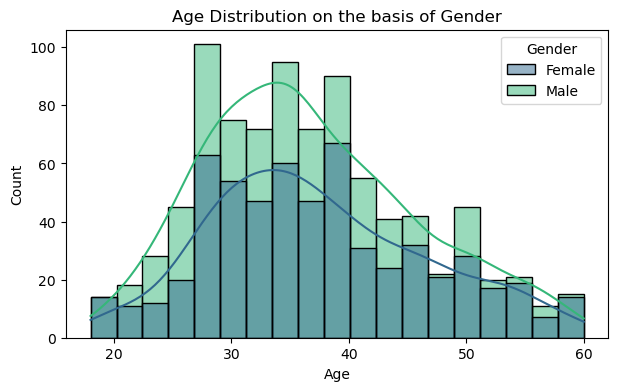

In [31]:
plt.figure(figsize=(7,4))
sns.histplot(x=data['Age'],kde=True,palette='viridis',hue=data['Gender'])
plt.title('Age Distribution on the basis of Gender')
plt.show()

Conclusion : Most of the males and females are of the age between 25 to 40 

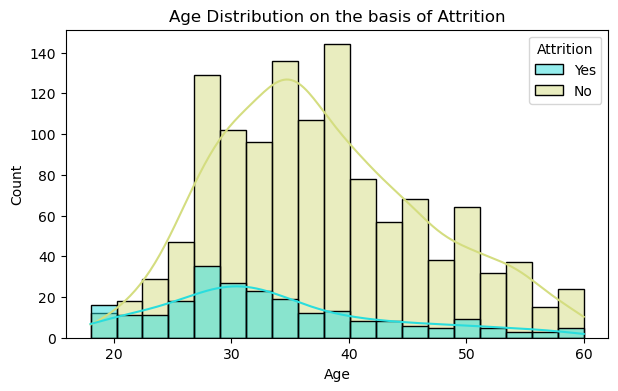

In [33]:
plt.figure(figsize=(7,4))
sns.histplot(x=data['Age'],kde=True,palette='rainbow',hue=data['Attrition'])
plt.title('Age Distribution on the basis of Attrition')
plt.show()

Conclusion : Most Employees Attrition is from the Age between 25-35

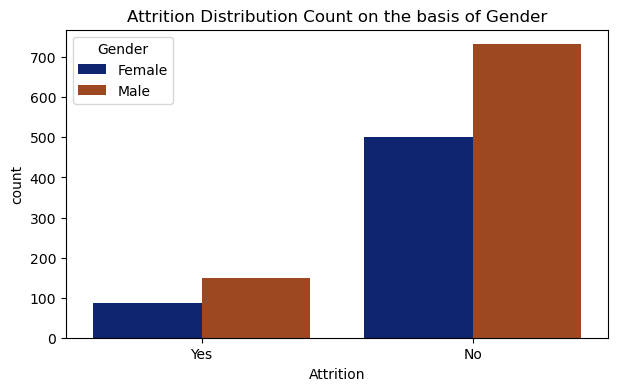

In [35]:
plt.figure(figsize=(7,4))
sns.countplot(x=data['Attrition'],palette='dark',hue=data['Gender'])
plt.title('Attrition Distribution Count on the basis of Gender')
plt.show()

Conclusion : Max Attrition is from MALES

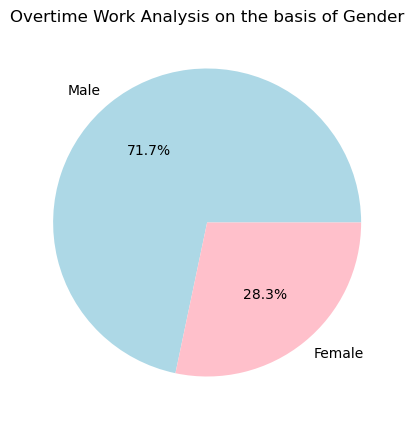

In [37]:
plt.figure(figsize=(7,5))
plt.pie(data['OverTime'].value_counts(), labels=data['Gender'].value_counts().index,colors=['lightblue','pink'],autopct='%1.1f%%')
plt.title('Overtime Work Analysis on the basis of Gender')
plt.show()

Conclusion : Males do 71.7% of Over time

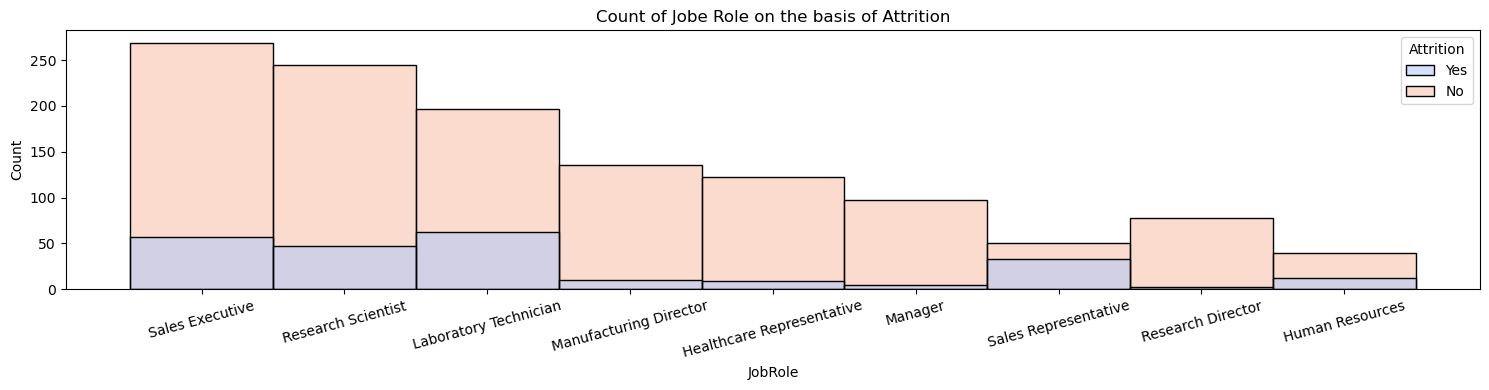

In [39]:
plt.figure(figsize=(15,4))
sns.histplot(x=data['JobRole'],palette='coolwarm',hue=data['Attrition'])
plt.title('Count of Jobe Role on the basis of Attrition')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Conclusion : Most Attrition is from Laboratory technician , Sales Executive and Research Scientists - Job Roles

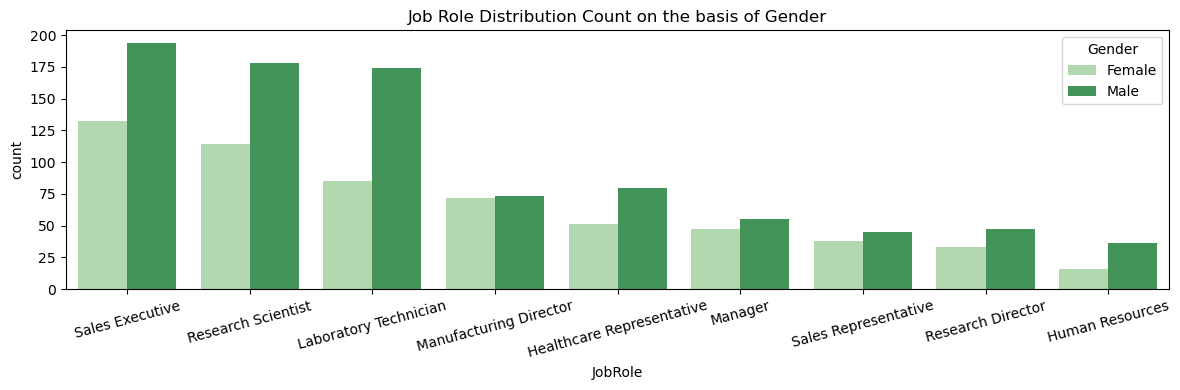

In [41]:
plt.figure(figsize=(12,4))
sns.countplot(x=data['JobRole'],palette='Greens',hue=data['Gender'])
plt.title('Job Role Distribution Count on the basis of Gender')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Conclusion : The Job Roles having maximum Attrition are mostly consists of Males

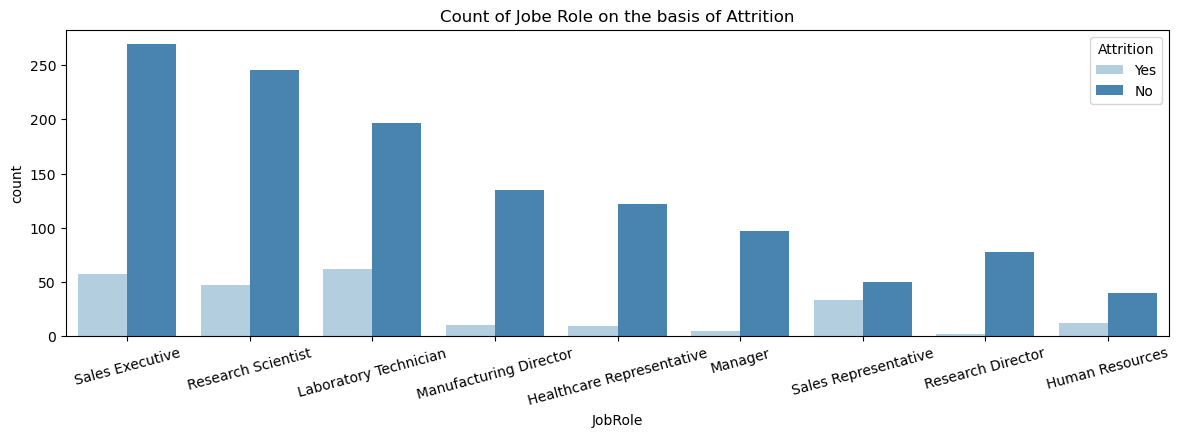

In [43]:
plt.figure(figsize=(12,4))
sns.countplot(x=data['JobRole'],palette='Blues',hue=data['Attrition'])
plt.title('Count of Jobe Role on the basis of Attrition')
plt.tight_layout()
plt.xticks(rotation=15)
plt.show()

Conclusion : Job Roles - Laboratory technician , Sales Executive and Research Scientists having maximum Attrition is may be because of Over Time

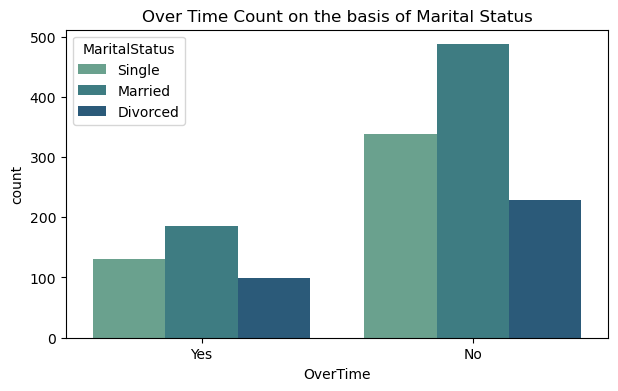

In [45]:
plt.figure(figsize=(7,4))
sns.countplot(x=data['OverTime'],palette='crest',hue=data['MaritalStatus'])
plt.title('Over Time Count on the basis of Marital Status')
plt.show()

Conclusion : Mostly Married people are doing Over Time

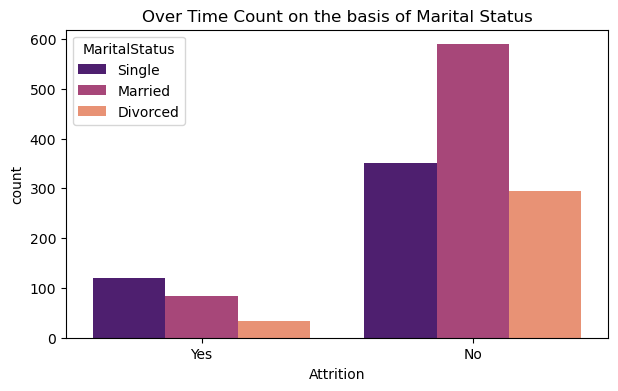

In [47]:
plt.figure(figsize=(7,4))
sns.countplot(x=data['Attrition'],palette='magma',hue=data['MaritalStatus'])
plt.title('Over Time Count on the basis of Marital Status')
plt.show()

Conclusion : Mostlt single people are Involved in Attrition

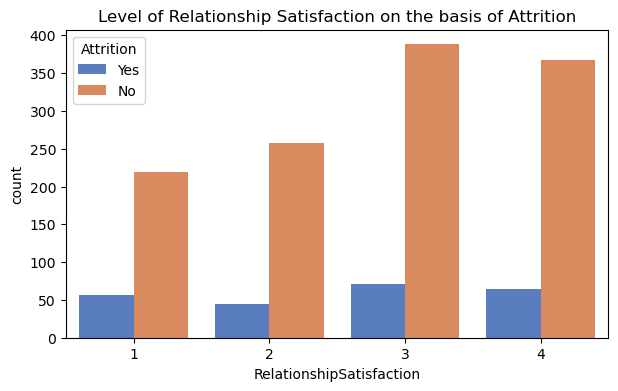

In [49]:
plt.figure(figsize=(7,4))
sns.countplot(x=data['RelationshipSatisfaction'],palette='muted',hue=data['Attrition'])
plt.title('Level of Relationship Satisfaction on the basis of Attrition')
plt.show()

Conclusion : Mostly people at level 3 and 4 of Relationship satisfaction are involved in Attrition

In [51]:
data['WorkLifeBalance'].value_counts()

WorkLifeBalance
3    893
2    344
4    153
1     80
Name: count, dtype: int64

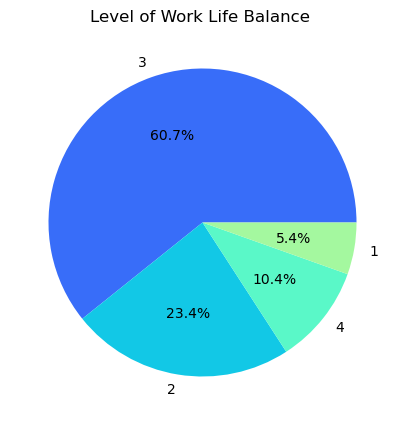

In [52]:
plt.figure(figsize=(7,5))
plt.pie(data['WorkLifeBalance'].value_counts().values, labels=data['WorkLifeBalance'].value_counts().index,colors=sns.color_palette('rainbow'),autopct='%1.1f%%')
plt.title('Level of Work Life Balance ')
plt.show()

Conclusion : Most of the Employee's Work Life Balance is at level 3

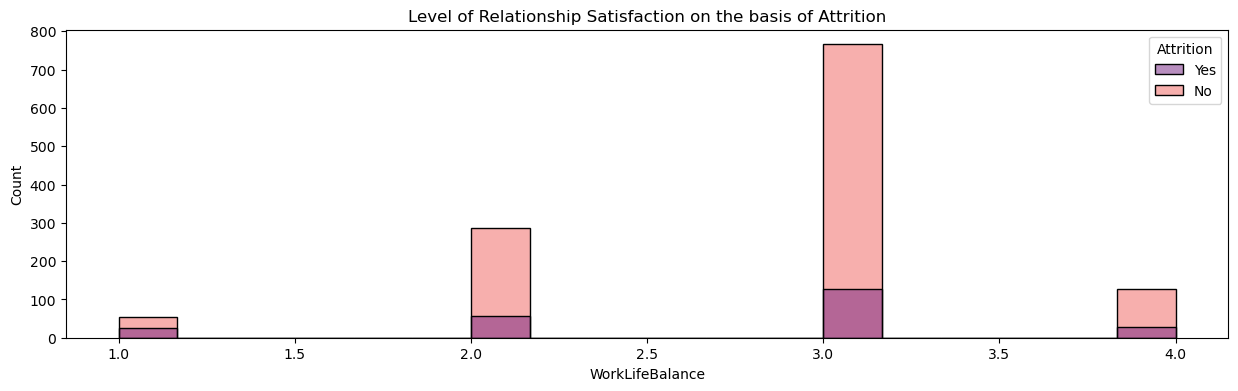

In [54]:
plt.figure(figsize=(15,4))
sns.histplot(x=data['WorkLifeBalance'],palette='magma',hue=data['Attrition'])
plt.title('Level of Relationship Satisfaction on the basis of Attrition')
plt.show()

Conclusion : Most of the Attrition is from the Employees at level 2 and 3 of Work Life Balance

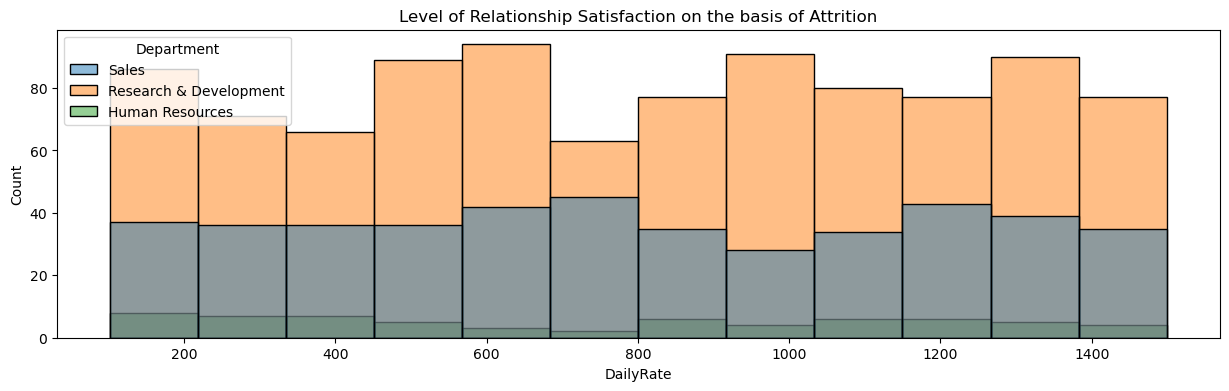

In [56]:
plt.figure(figsize=(15,4))
sns.histplot(x=data['DailyRate'],color=['yellow','blue','red'],hue=data['Department'])
plt.title('Level of Relationship Satisfaction on the basis of Attrition')
plt.show()

Conclusion : Very less Daily Rate of Employees are from Human Resource Department

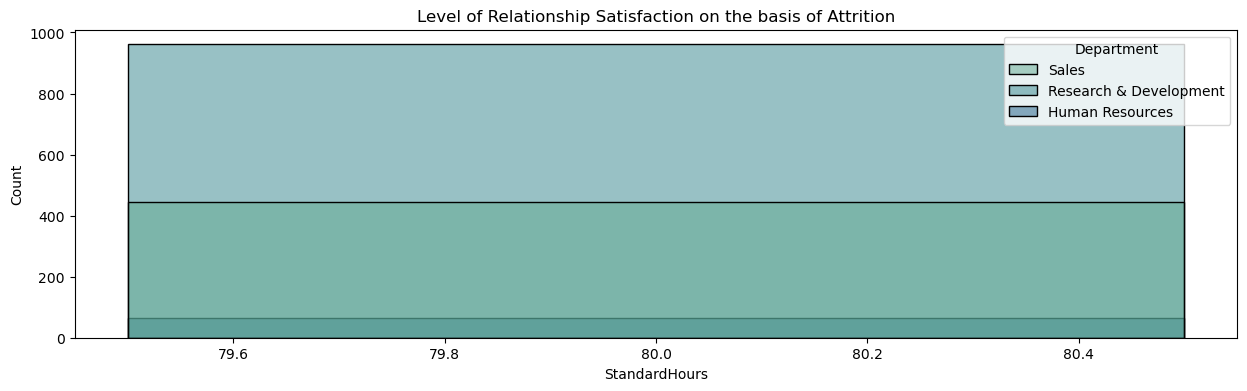

In [58]:
plt.figure(figsize=(15,4))
sns.histplot(x=data['StandardHours'],palette='crest',hue=data['Department'])
plt.title('Level of Relationship Satisfaction on the basis of Attrition')
plt.show()

Conclusion : Standard Working Hours for every Department is Equivalent

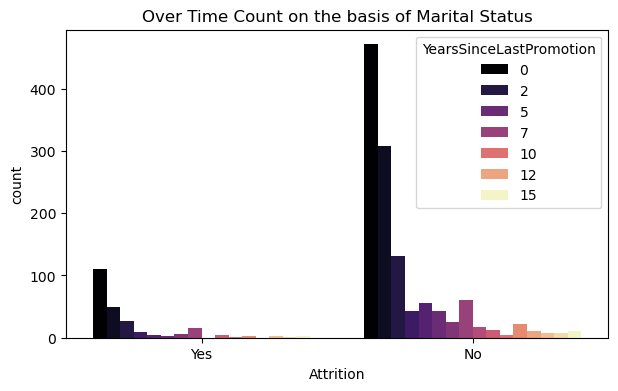

In [60]:
plt.figure(figsize=(7,4))
sns.countplot(x=data['Attrition'],palette='magma',hue=data['YearsSinceLastPromotion'])
plt.title('Over Time Count on the basis of Marital Status')
plt.show()

Conclusion : Employees Attrition is seen who's Promotion was nearly 0 years ago , it was done or not ,also 7 years since last promotion.

Adding a new column for the final score of the employees

In [63]:
data['final_score'] =   np.where(
    data['Attrition'] == 'No',
    np.round(
        (0.3 * data['JobInvolvement'] / data['JobInvolvement'].max() +
         0.3 * data['PerformanceRating'] / data['PerformanceRating'].max() +
         0.2 * data['WorkLifeBalance'] / data['WorkLifeBalance'].max() +
         0.1 * data['JobLevel'] / data['JobLevel'].max() +
         0.1 * data['MonthlyIncome'] / data['MonthlyIncome'].max()) * 10
    ).astype(int),  # Round and convert to integer
    np.nan  # For employees with Attrition = "Yes", keep it as NaN
)
data.dropna(subset=['final_score'], inplace=True)

In [64]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,final_score
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,7.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,6.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,6.0
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,80,0,8,2,2,7,7,3,6,6.0
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,80,3,12,3,2,1,0,0,0,7.0


C:\Users\lenovo 2020\AppData\Local\Temp\ipykernel_14708\2000701459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='final_score', data=data, palette="Set2")


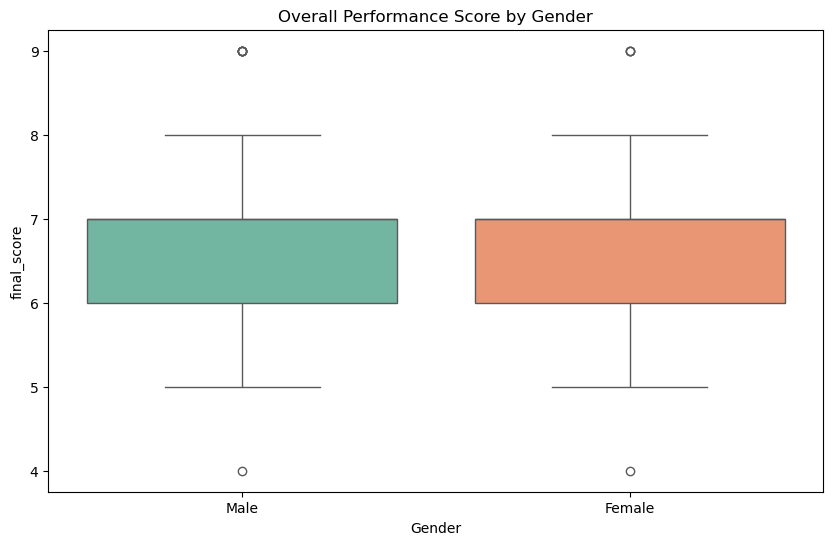

In [65]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='final_score', data=data, palette="Set2")
plt.title('Overall Performance Score by Gender')
plt.show()

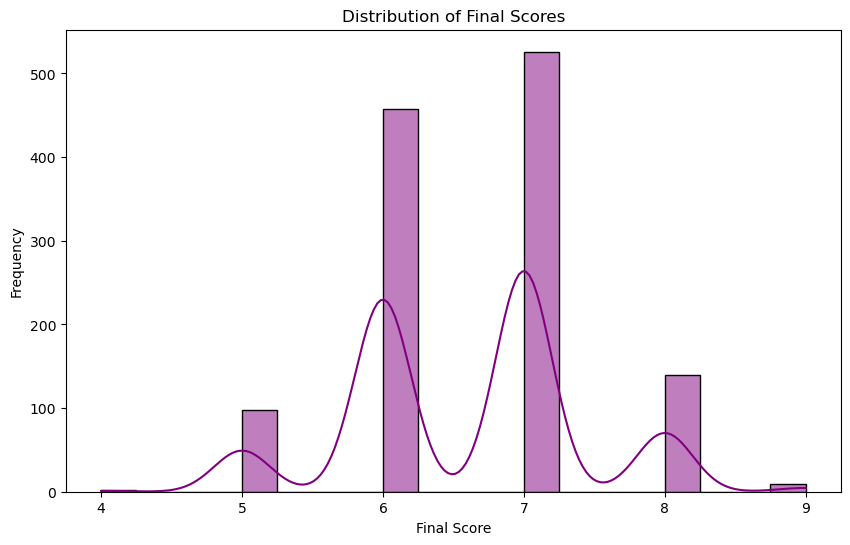

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(data['final_score'], kde=True, bins=20,color='purple')
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()

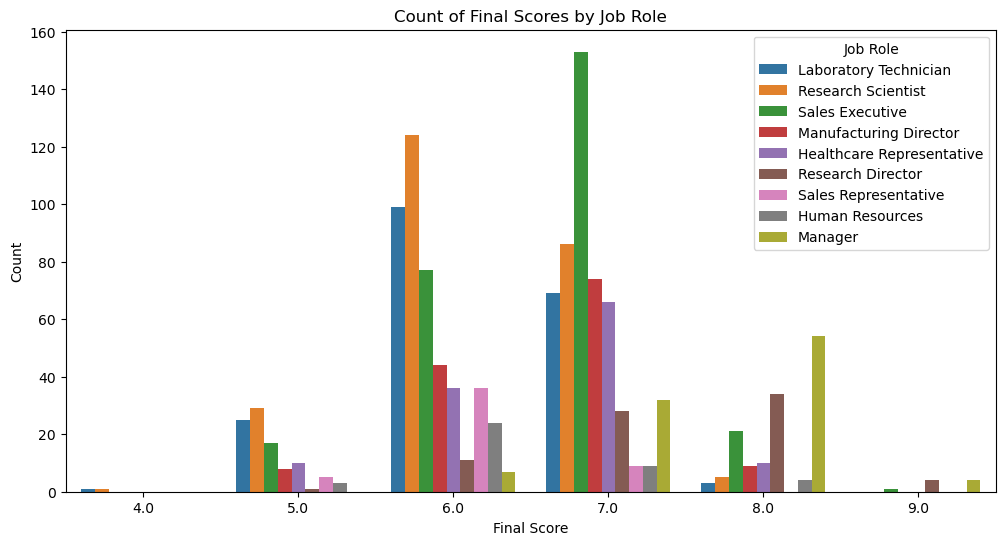

In [67]:
plt.figure(figsize=(12, 6))
sns.countplot(x='final_score', hue='JobRole', data=data)
plt.title('Count of Final Scores by Job Role')
plt.xlabel('Final Score')
plt.ylabel('Count')
plt.legend(title='Job Role')
plt.show()

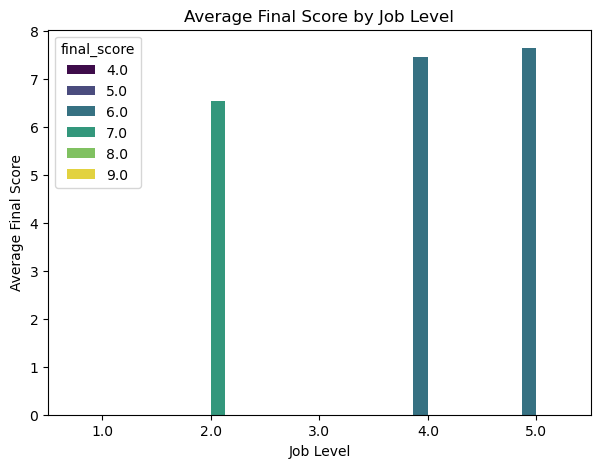

In [68]:
avg_performance_by_job_level = data.groupby('JobLevel')['final_score'].mean().reset_index()
plt.figure(figsize=(7,5))
sns.barplot(x='JobLevel', y='final_score', data=avg_performance_by_job_level,hue=data['final_score'],palette='viridis')
plt.title('Average Final Score by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Average Final Score')
plt.show()

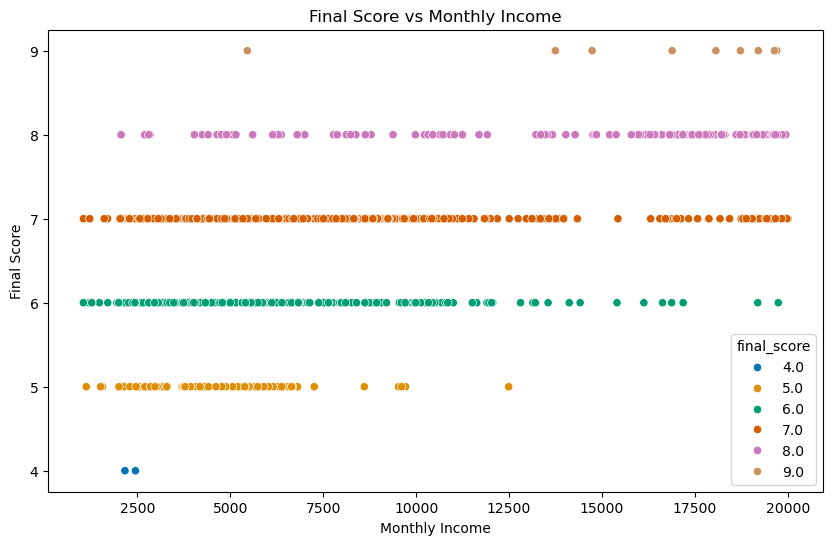

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MonthlyIncome', y='final_score', data=data,hue=data['final_score'],palette='colorblind')
plt.title('Final Score vs Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Final Score')
plt.show()

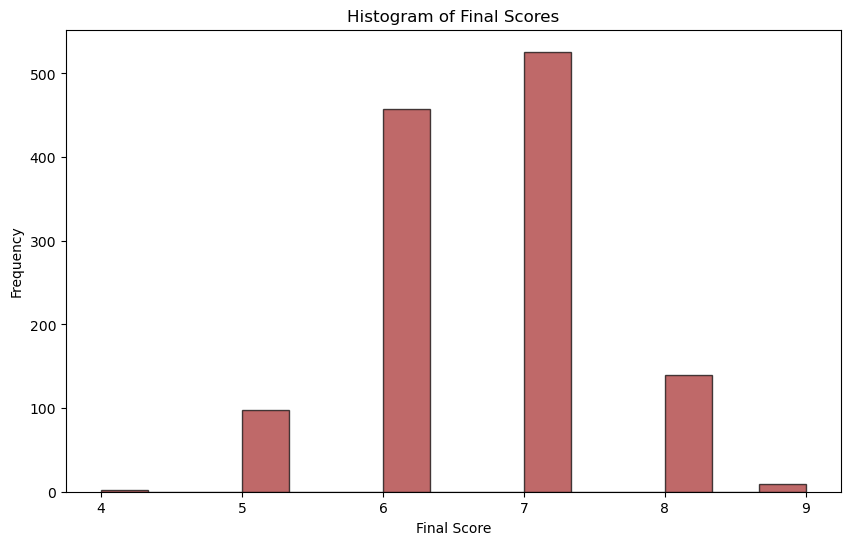

In [70]:
plt.figure(figsize=(10, 6))
plt.hist(data['final_score'], bins=15, alpha=0.7, color='brown',edgecolor='black')
plt.title('Histogram of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x800 with 0 Axes>

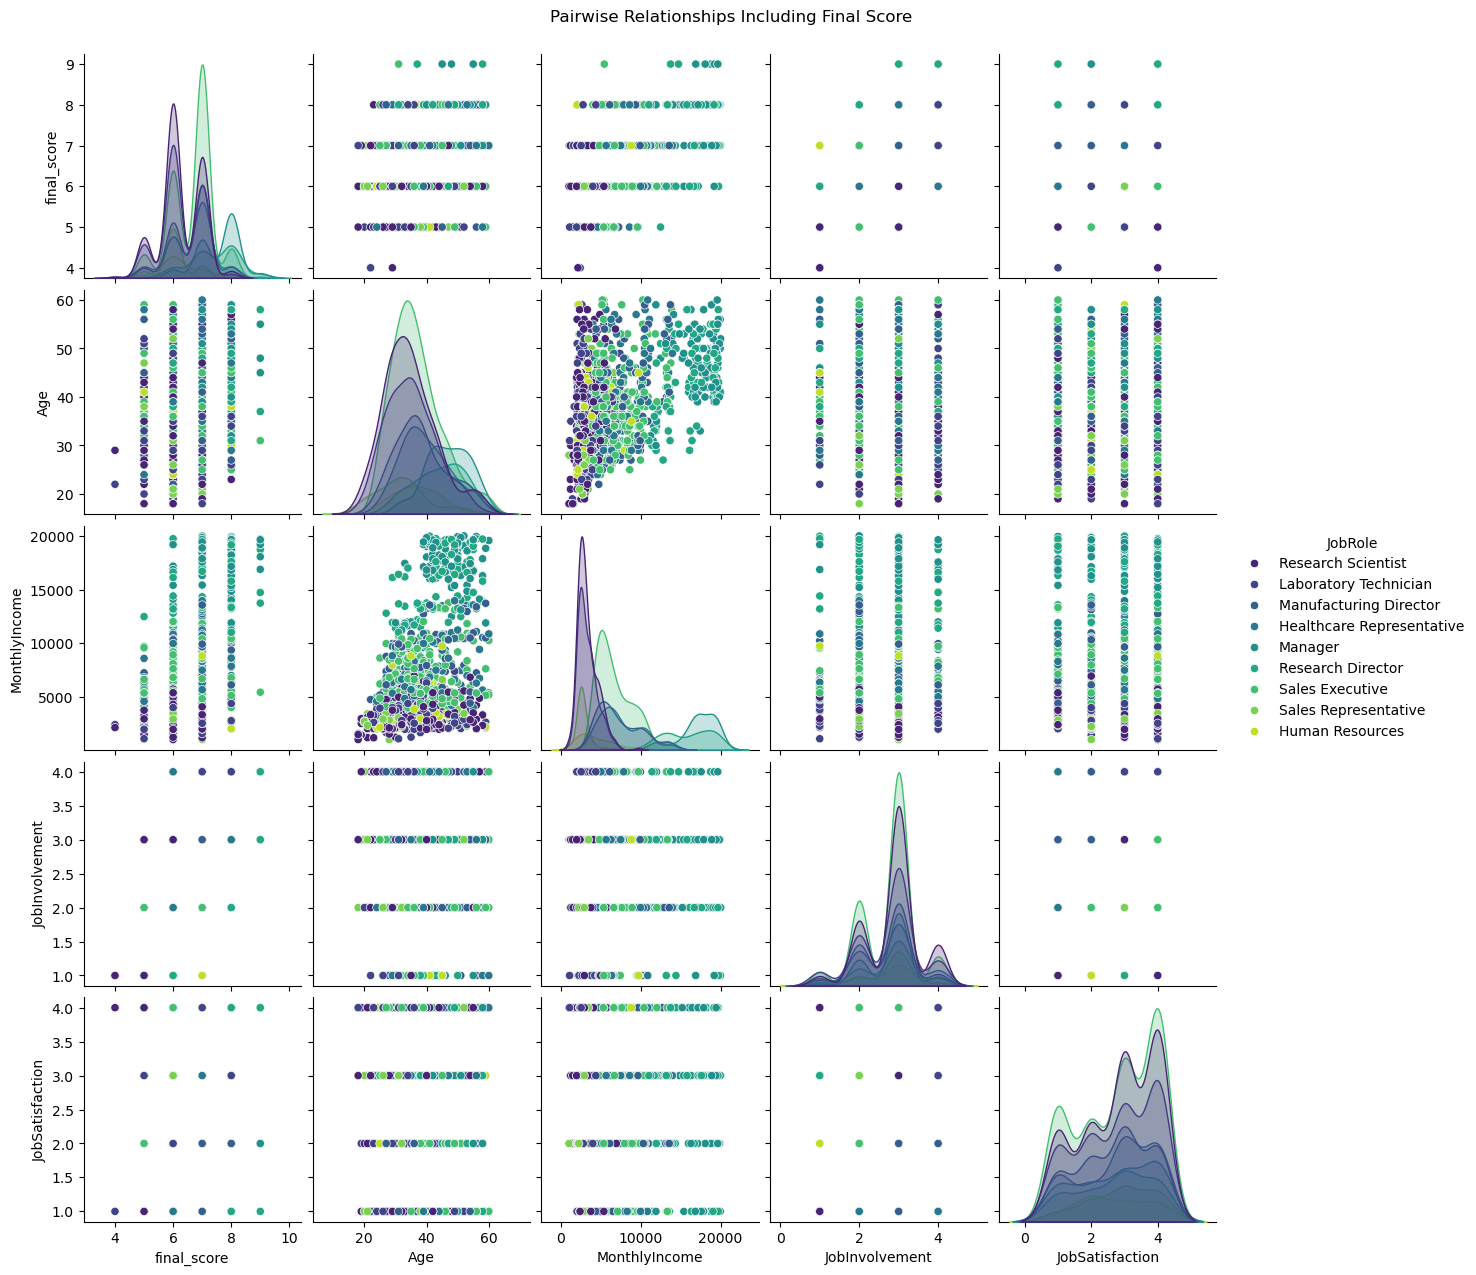

In [71]:
numerical_columns = ['final_score', 'Age', 'MonthlyIncome', 'JobInvolvement', 'JobSatisfaction']
plt.figure(figsize=(10, 8))
sns.pairplot(data[numerical_columns].assign(JobRole=data['JobRole']), hue='JobRole', palette='viridis')
plt.suptitle('Pairwise Relationships Including Final Score', y=1.02)  # Adjust title position
plt.show()

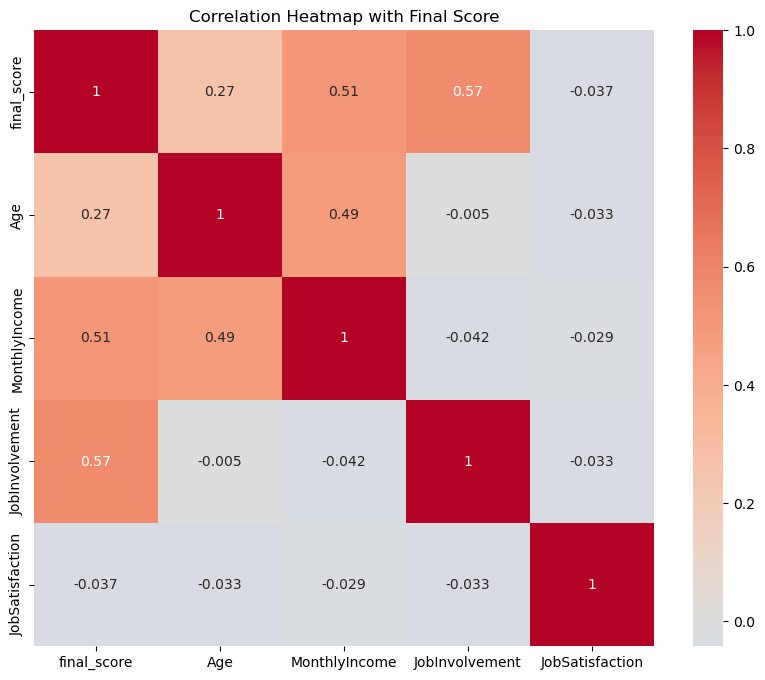

In [72]:
plt.figure(figsize=(10, 8))
correlation = data[numerical_columns].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap with Final Score')
plt.show()

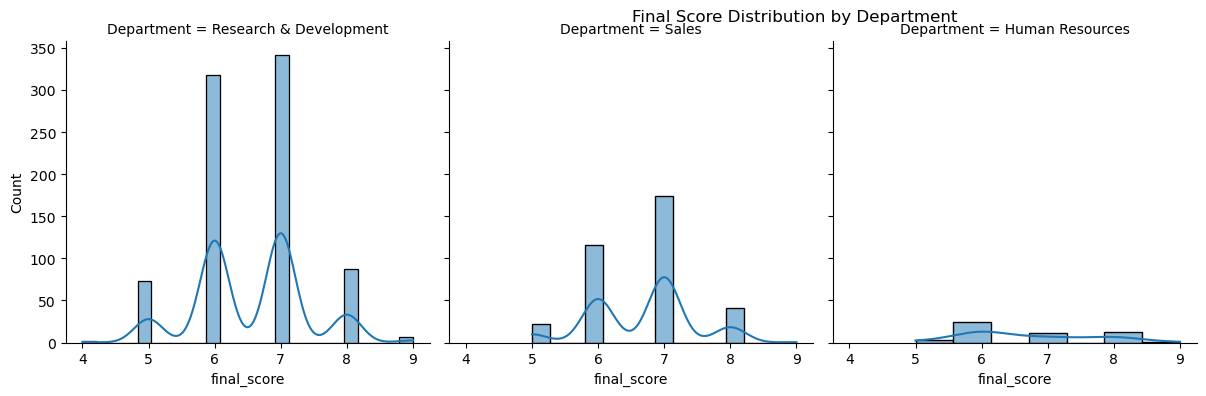

In [73]:
g = sns.FacetGrid(data, col='Department', col_wrap=4, height=4, palette='pastel')
g.map(sns.histplot, 'final_score', kde=True)
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Final Score Distribution by Department')
plt.show()

DATA OVERVIEW -  FOR PREDICTION 

In [75]:
data.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,final_score
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,7.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,6.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,6.0
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,80,0,8,2,2,7,7,3,6,6.0
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,80,3,12,3,2,1,0,0,0,7.0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,80,1,1,2,3,1,0,0,0,7.0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,80,0,10,2,3,9,7,1,8,7.0
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,80,2,17,3,2,7,7,7,7,6.0
10,35,No,Travel_Rarely,809,Research & Development,16,3,Medical,1,14,...,80,1,6,5,3,5,4,0,3,7.0
11,29,No,Travel_Rarely,153,Research & Development,15,2,Life Sciences,1,15,...,80,0,10,3,3,9,5,0,8,6.0


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 1 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1233 non-null   int64  
 1   Attrition                 1233 non-null   object 
 2   BusinessTravel            1233 non-null   object 
 3   DailyRate                 1233 non-null   int64  
 4   Department                1233 non-null   object 
 5   DistanceFromHome          1233 non-null   int64  
 6   Education                 1233 non-null   int64  
 7   EducationField            1233 non-null   object 
 8   EmployeeCount             1233 non-null   int64  
 9   EmployeeNumber            1233 non-null   int64  
 10  EnvironmentSatisfaction   1233 non-null   int64  
 11  Gender                    1233 non-null   object 
 12  HourlyRate                1233 non-null   int64  
 13  JobInvolvement            1233 non-null   int64  
 14  JobLevel     

In [77]:
data.select_dtypes(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
5,No,Travel_Frequently,Research & Development,Life Sciences,Male,Laboratory Technician,Single,Y,No
6,No,Travel_Rarely,Research & Development,Medical,Female,Laboratory Technician,Married,Y,Yes
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [78]:
data.select_dtypes(include='int64')

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
5,32,1005,2,2,1,8,4,79,3,1,...,3,80,0,8,2,2,7,7,3,6
6,59,1324,3,3,1,10,3,81,4,1,...,1,80,3,12,3,2,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


DATA PREPROCESSING AND CLEANING

In [80]:
data.isnull().sum().sum()

0

In [81]:
data.shape

(1233, 36)

In [82]:
data.drop_duplicates()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,final_score
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,7.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,6.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,6.0
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,80,0,8,2,2,7,7,3,6,6.0
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,80,3,12,3,2,1,0,0,0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,80,1,17,3,3,5,2,0,3,7.0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,80,1,9,5,3,7,7,1,7,6.0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,80,1,6,0,3,6,2,0,3,8.0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,80,0,17,3,2,9,6,0,8,5.0


In [83]:
data.shape

(1233, 36)

CHECKING OUTLIERS THROUGH BOXPLOT

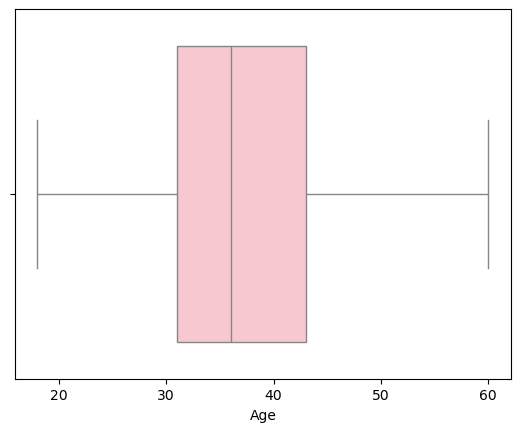

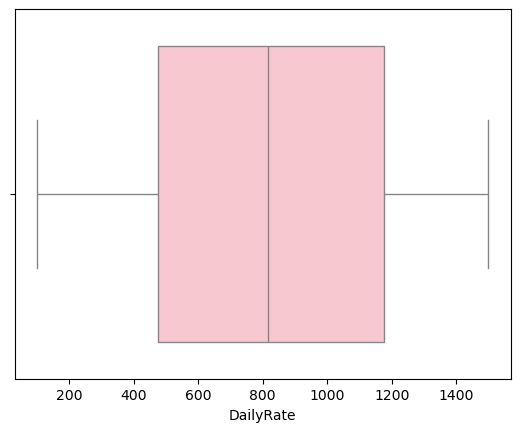

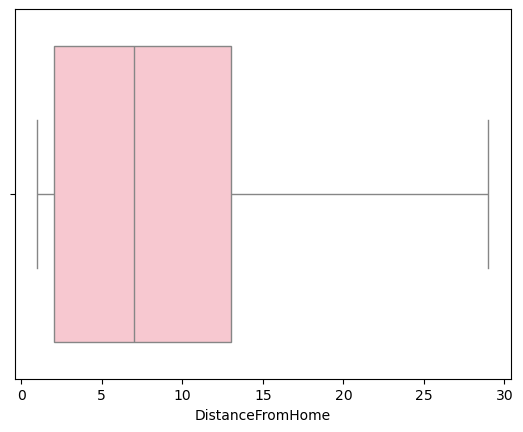

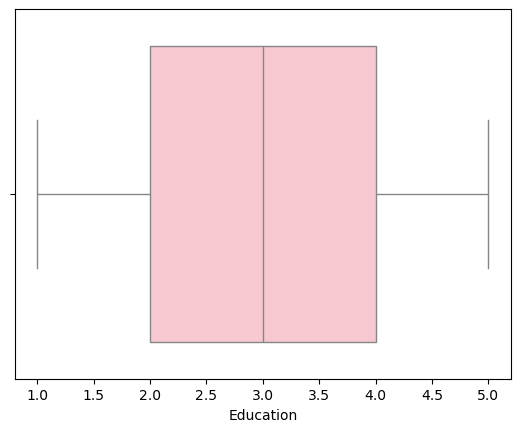

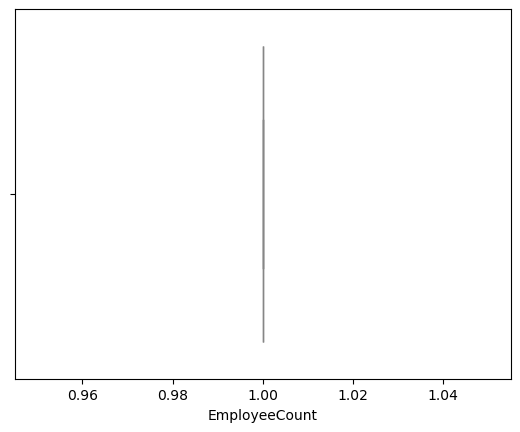

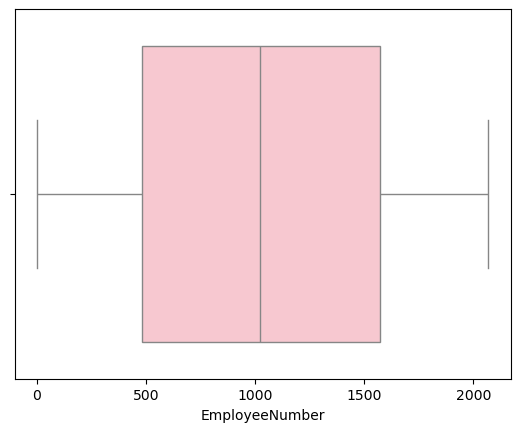

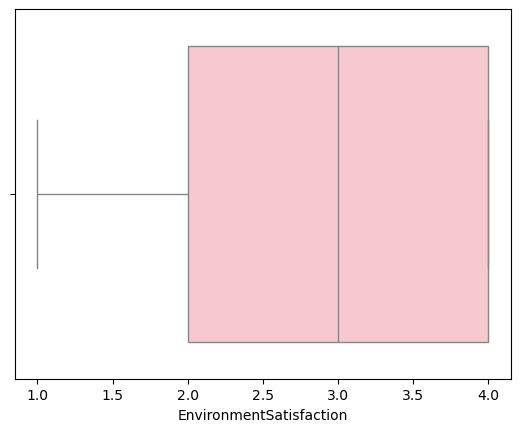

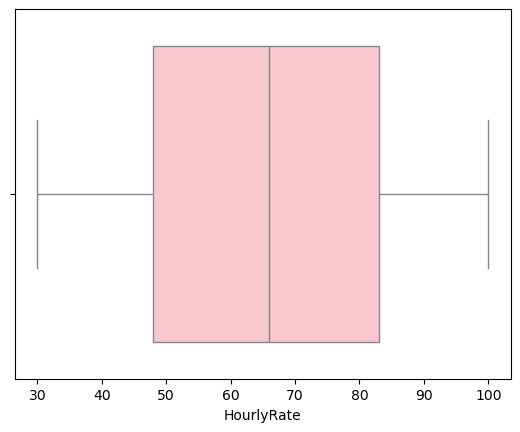

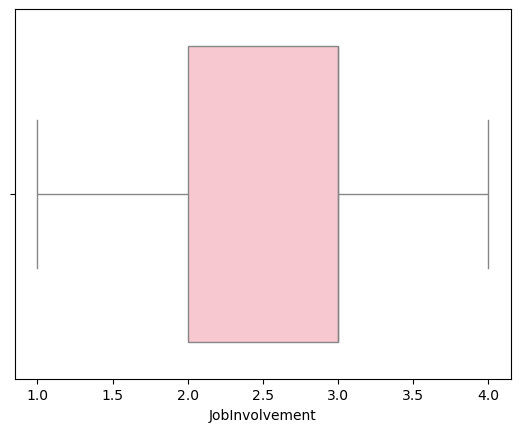

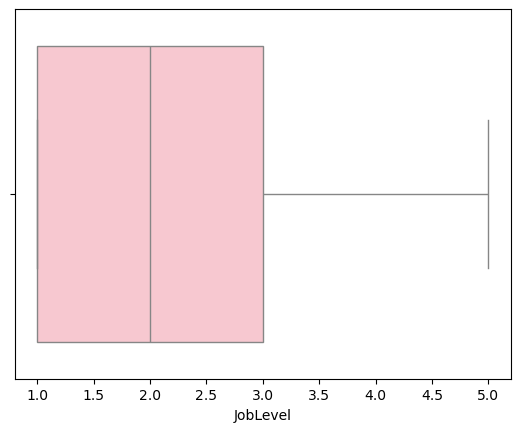

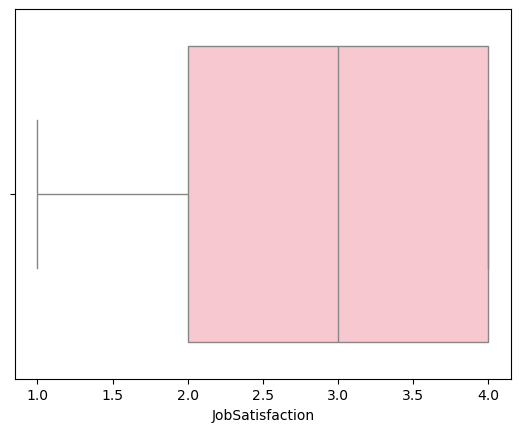

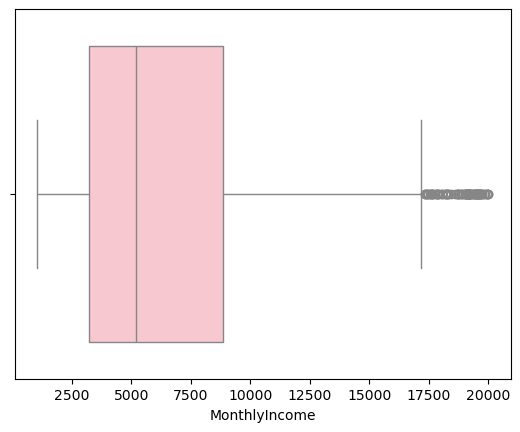

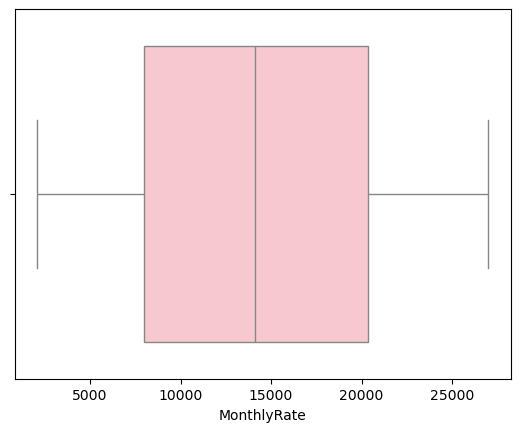

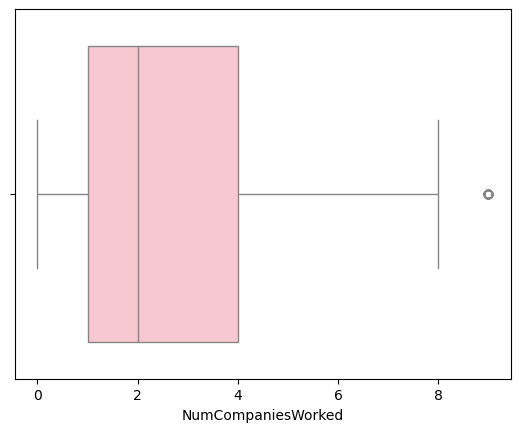

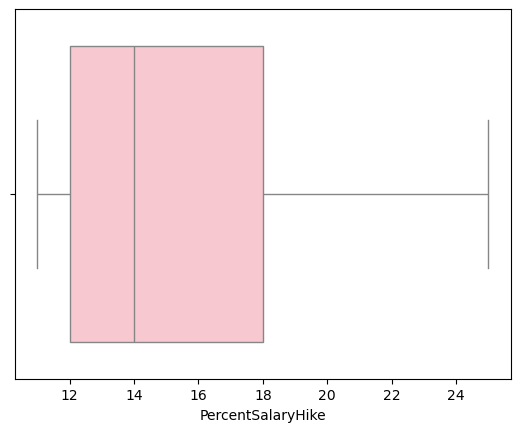

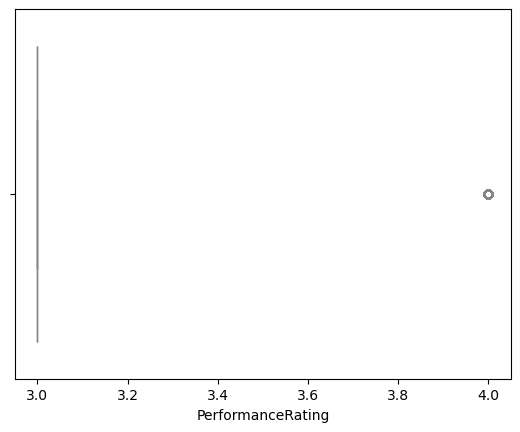

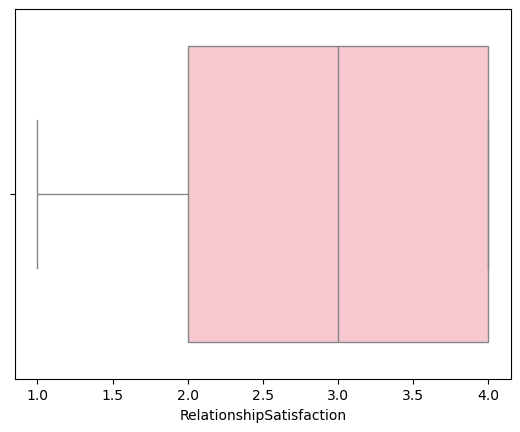

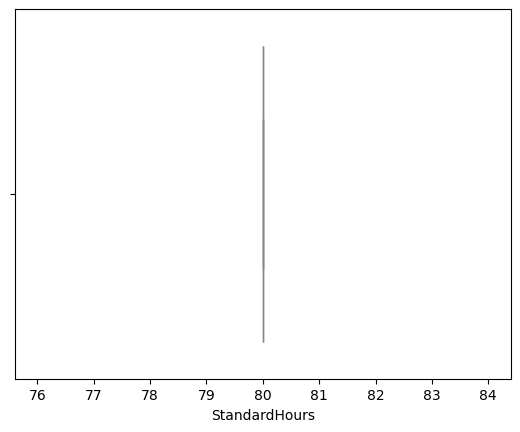

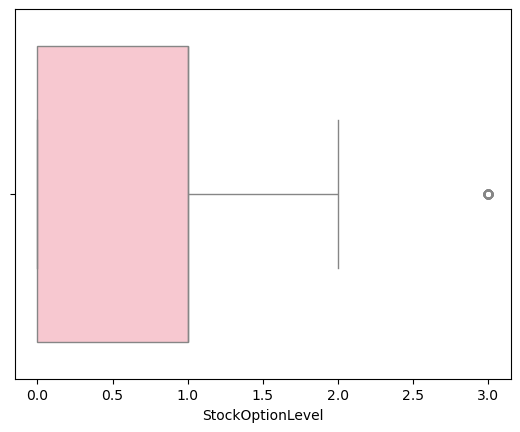

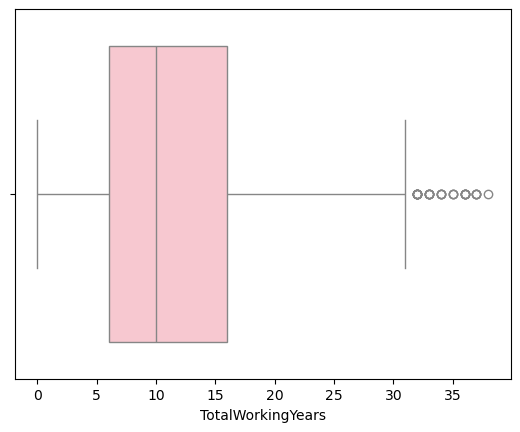

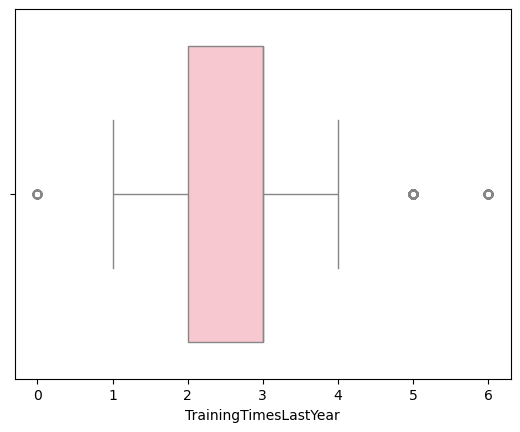

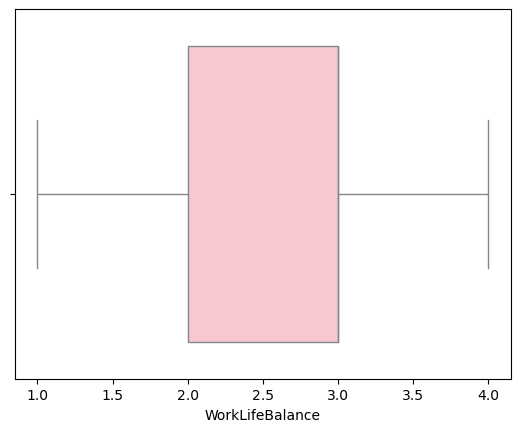

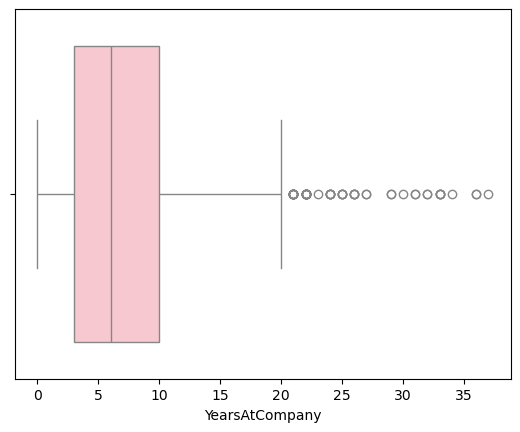

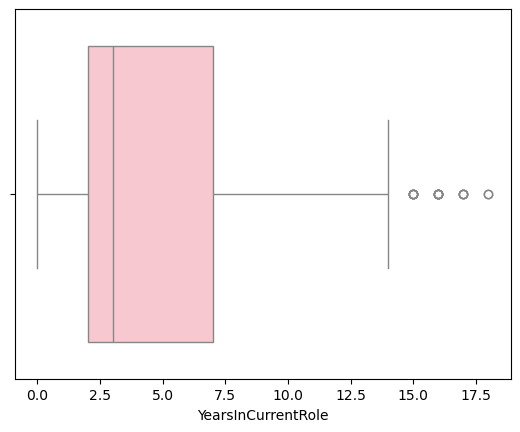

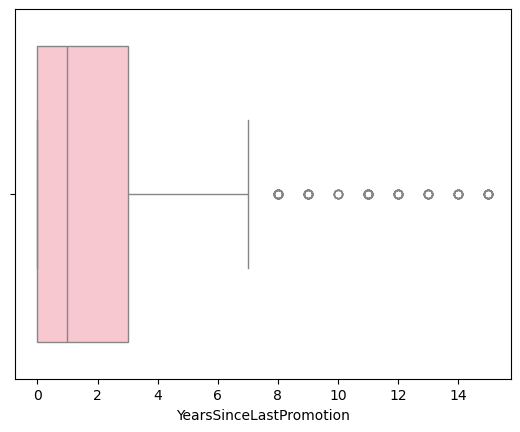

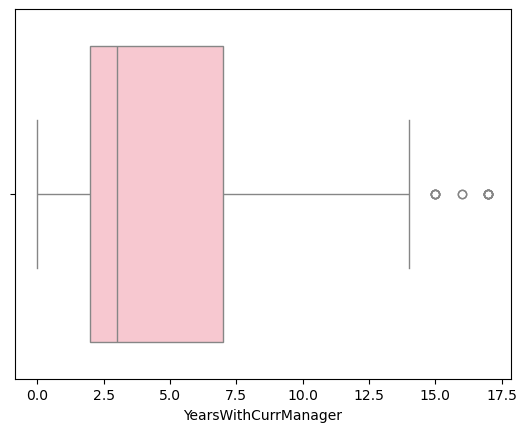

In [85]:
num_col=data.select_dtypes(include='int64')
for i in num_col :
    sns.boxplot(x=data[i],color='pink')
    plt.show()

Conclusion : Most of the Outliers are present in - Monthly Income and rest of the outliers are less so they don't effect the data that much ! so they can be ignored

In [87]:
new_dataset=data.copy()

Performing Operations on new dataset as to preserve original dataset

In [89]:
Q1=data['MonthlyIncome'].quantile(0.25)
Q3=data['MonthlyIncome'].quantile(0.75)
IQR=Q3-Q1
min_range=Q1-(1.5*IQR)
max_range=Q3+(1.5*IQR)
new_dataset['MonthlyIncome']=data['MonthlyIncome']<=max_range

Removing Outliers Using - IQR method

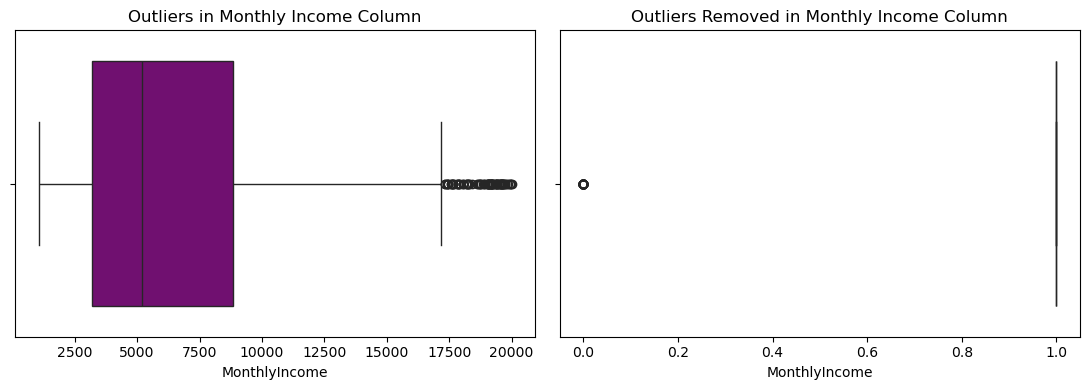

In [91]:
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
sns.boxplot(x=data['MonthlyIncome'],color='purple')
plt.title('Outliers in Monthly Income Column')
plt.subplot(1,2,2) 
sns.boxplot(x=new_dataset['MonthlyIncome'],color='green')
plt.title('Outliers Removed in Monthly Income Column')
plt.tight_layout()
plt.show()

Conclusion : Outliers Removed

In [93]:
data=new_dataset

In [94]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,final_score
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,7.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,6.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,6.0
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,80,0,8,2,2,7,7,3,6,6.0
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,80,3,12,3,2,1,0,0,0,7.0


In [95]:
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 1 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1233 non-null   int64  
 1   Attrition                 1233 non-null   int32  
 2   BusinessTravel            1233 non-null   int32  
 3   DailyRate                 1233 non-null   int64  
 4   Department                1233 non-null   int32  
 5   DistanceFromHome          1233 non-null   int64  
 6   Education                 1233 non-null   int64  
 7   EducationField            1233 non-null   int32  
 8   EmployeeCount             1233 non-null   int64  
 9   EmployeeNumber            1233 non-null   int64  
 10  EnvironmentSatisfaction   1233 non-null   int64  
 11  Gender                    1233 non-null   int32  
 12  HourlyRate                1233 non-null   int64  
 13  JobInvolvement            1233 non-null   int64  
 14  JobLevel     

In [97]:
scaler = StandardScaler()
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns.drop(['EmployeeNumber', 'final_score'])
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [98]:
X_regression = data.drop(columns=['EmployeeNumber', 'final_score'])
y_regression = data['final_score'].dropna()

In [99]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)

In [100]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

# Dictionary to store model performance for regression
regression_model_performance = {}

In [101]:
for model_name, model in regression_models.items():
    # Train model
    model.fit(X_train_reg, y_train_reg)
    
    # Predict and evaluate
    y_pred_reg = model.predict(X_test_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    # Store results
    regression_model_performance[model_name] = {
        "MSE": mse,
        "R2 Score": r2
    }
    print(f"{model_name} - MSE: {mse:.4f}, R2 Score: {r2:.4f}")

Linear Regression - MSE: 0.0917, R2 Score: 0.8744
Random Forest Regressor - MSE: 0.0754, R2 Score: 0.8968
Support Vector Regressor - MSE: 0.1216, R2 Score: 0.8335
Gradient Boosting Regressor - MSE: 0.0686, R2 Score: 0.9061


In [102]:
best_regression_model = max(regression_model_performance, key=lambda x: regression_model_performance[x]['R2 Score'])
print(f"\nBest Regression Model: {best_regression_model} with R2 Score: {regression_model_performance[best_regression_model]['R2 Score']:.4f}")


Best Regression Model: Gradient Boosting Regressor with R2 Score: 0.9061


In [103]:
average_score = data['final_score'].mean()
data['Score_Category'] = np.where(data['final_score'] > average_score, 1, 0)

In [104]:
X_classification = data.drop(columns=[ 'EmployeeNumber', 'final_score', 'Score_Category'])
y_classification = data['Score_Category'].dropna()

In [105]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42)

In [106]:
classification_models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "Support Vector Classifier": SVC(),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42)
}
classification_model_performance = {}

In [107]:
for model_name, model in classification_models.items():
    # Train model
    model.fit(X_train_class, y_train_class)
    
    # Predict and evaluate
    y_pred_class = model.predict(X_test_class)
    accuracy = accuracy_score(y_test_class, y_pred_class)
    
    # Store results
    classification_model_performance[model_name] = {
        "Accuracy": accuracy
    }
    print(f"{model_name} - Accuracy: {accuracy:.4f}")

Logistic Regression - Accuracy: 0.9879
Random Forest Classifier - Accuracy: 0.9676
Support Vector Classifier - Accuracy: 0.9555
Gradient Boosting Classifier - Accuracy: 0.9838


In [108]:
best_classification_model = max(classification_model_performance, key=lambda x: classification_model_performance[x]['Accuracy'])
print(f"\nBest Classification Model: {best_classification_model} with Accuracy: {classification_model_performance[best_classification_model]['Accuracy']:.4f}")


Best Classification Model: Logistic Regression with Accuracy: 0.9879


In [109]:
X_classification = pd.get_dummies(X_classification, drop_first=True)

In [110]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification, 
    y_classification, 
    test_size=0.2, 
    random_state=42
)

In [111]:
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train_class, y_train_class)

LogisticRegression(max_iter=200, random_state=42)

In [112]:
y_pred_class = model.predict(X_test_class)

In [113]:
accuracy = accuracy_score(y_test_class, y_pred_class)
report = classification_report(y_test_class, y_pred_class)

# Output results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       104
           1       0.99      0.99      0.99       143

    accuracy                           0.99       247
   macro avg       0.99      0.99      0.99       247
weighted avg       0.99      0.99      0.99       247



In [265]:
sample_data = {
    'Age': 35,                         # Older employees may have higher scores
    'DailyRate': 9000,                  # Higher daily rates could indicate better performance
    'DistanceFromHome': 1,             # Closer distance may imply better work-life balance
    'Education': 5,                     # Example: encoded for Master's degree
    'EnvironmentSatisfaction': 5,      # Higher satisfaction often leads to better performance
    'Gender': 1,                       # Male (if encoded as 1)
    'JobInvolvement': 5,               # High job involvement could boost the score
    'JobLevel': 5,                     # Higher job level may lead to a higher score
    'JobSatisfaction': 5,              # High job satisfaction
    'MonthlyIncome': 60000              # Higher income often reflects better performance
}
input_df = pd.DataFrame([sample_data])

In [269]:
input_df = pd.get_dummies(input_df, drop_first=True) 

In [271]:
input_df = input_df.reindex(columns=X_train_class.columns, fill_value=0)

In [273]:
predicted_final_score = model.predict(input_df)
print(f"Predicted Final Score: {predicted_final_score[0]}")

Predicted Final Score: 0
